# Scoring de fondos mutuos — informe técnico

**Caso técnico — Analista de Inversiones, Renta Variable Indirecta**

El objetivo es construir un modelo cuantitativo que asigne un puntaje a
cada fondo del universo de manera de informar la decisión de inversión,
distinguiendo fondos atractivos de poco atractivos. Más que la precisión
absoluta del modelo, el énfasis está en la **definición del problema**,
la **construcción de features**, la **disciplina anti-leakage** del
esquema de validación, y la **honestidad estadística** de los resultados.

Este notebook es la capa de reporting del pipeline. La lógica vive en
`src/` y se ejecuta vía scripts en `scripts/`. Reproducibilidad end-to-end:

```
uv sync
uv run python -m scripts.01_build_features
uv run python -m scripts.02_eda_report
uv run python -m scripts.03_build_features_full
uv run python -m scripts.04_train_and_evaluate
uv run python -m scripts.05_build_app_data
```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACTS = ROOT / "artifacts"
PLOTS = ARTIFACTS / "plots"

with open(ARTIFACTS / "metrics.json") as f:
    metrics = json.load(f)
panel = pd.read_parquet(ARTIFACTS / "panel_features.parquet")
scores = pd.read_parquet(ARTIFACTS / "scores.parquet")
coefs = pd.read_csv(ARTIFACTS / "drivers_elastic.csv")

## 1. Definición del problema

**Variable a predecir:** percentil cross-seccional del retorno total a 12
meses forward, dentro del universo activo en cada fecha.

**Justificación de esta elección:**

1. *Cross-seccional* — el equipo de inversión decide entre fondos en un
   momento dado; el ranking es la unidad de decisión natural, no el
   retorno absoluto. Predecir percentil hace al target robusto a regímenes
   de mercado (no se contamina con la dirección del beta del universo).
2. *12 meses forward* — horizonte alineado con el holding period típico
   de un manager de fondos en un fondo de pensiones, y suficiente para
   promediar ruido mensual.
3. *Total return* — incluye eventos de capital (`evento_pct`) además del
   cambio de NAV. Esto capta correctamente la rentabilidad efectiva del
   inversionista.

**Enfoque elegido: explicativo > predictivo.** Las razones:

- Audiencia del modelo (comité de inversiones) entiende factores y
  exposiciones, no SHAP de modelos black-box. La interpretabilidad importa.
- El universo es de 277 fondos × ~120 meses → la cantidad efectiva de
  observaciones es modesta para sostener modelos de alta capacidad.
- La literatura sugiere que la persistencia de retornos netos de fondos
  mutuos es débil (Carhart 1997, Berk & Green 2004, Fama-French 2010);
  un modelo explicativo bien calibrado es defensable, un black-box que
  afirma alta capacidad predictiva no.

Modelo principal: **ElasticNet**. Sanity check: **LightGBM** — si supera
al lineal por margen claro, hay no-linealidad real; si no, prevalece la
simplicidad.

## 2. Validación de datos contra el brief

Antes de ingenierizar features verifico cada uno de los 4 ítems descritos
en el brief. Los plots referenciados están en `artifacts/plots/`.

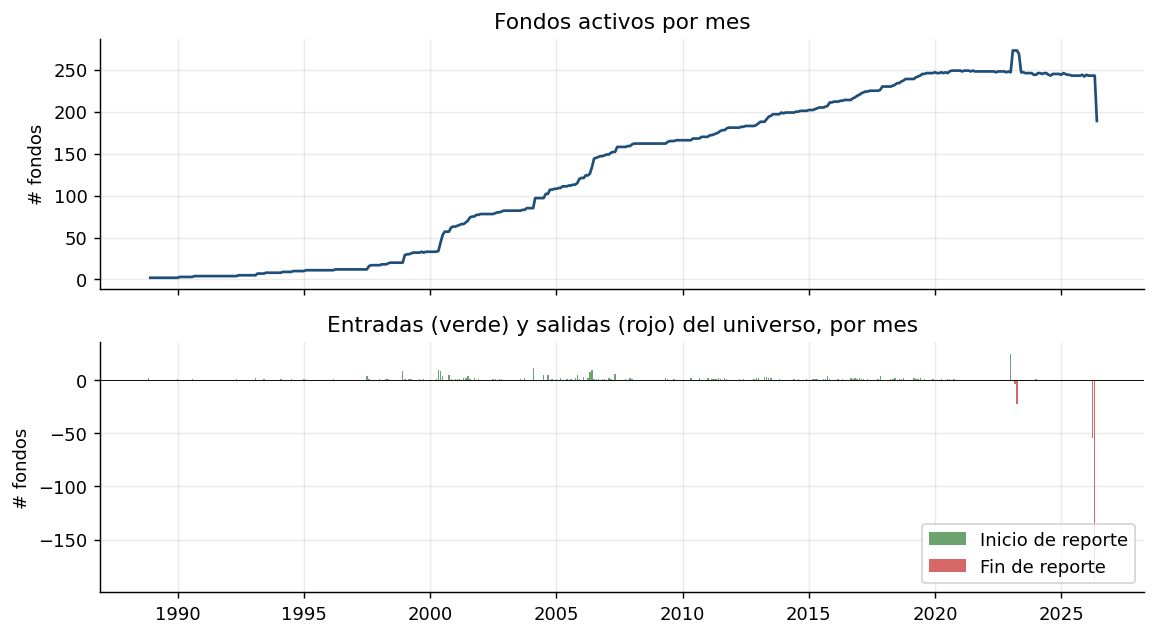

In [2]:
display(Image(filename=str(PLOTS / "cobertura_universo.png")))

**Hallazgo 1 — cobertura del universo.** El dataset trae 277 fondos, con
entradas distribuidas a lo largo de las décadas y salidas materiales
durante la GFC (2008-2009) y nuevamente en 2020. Esta heterogeneidad
temporal exige (a) restringir la ventana modelable a un período donde el
universo activo sea significativo y (b) tratar explícitamente el sesgo
de supervivencia en la interpretación de los resultados.

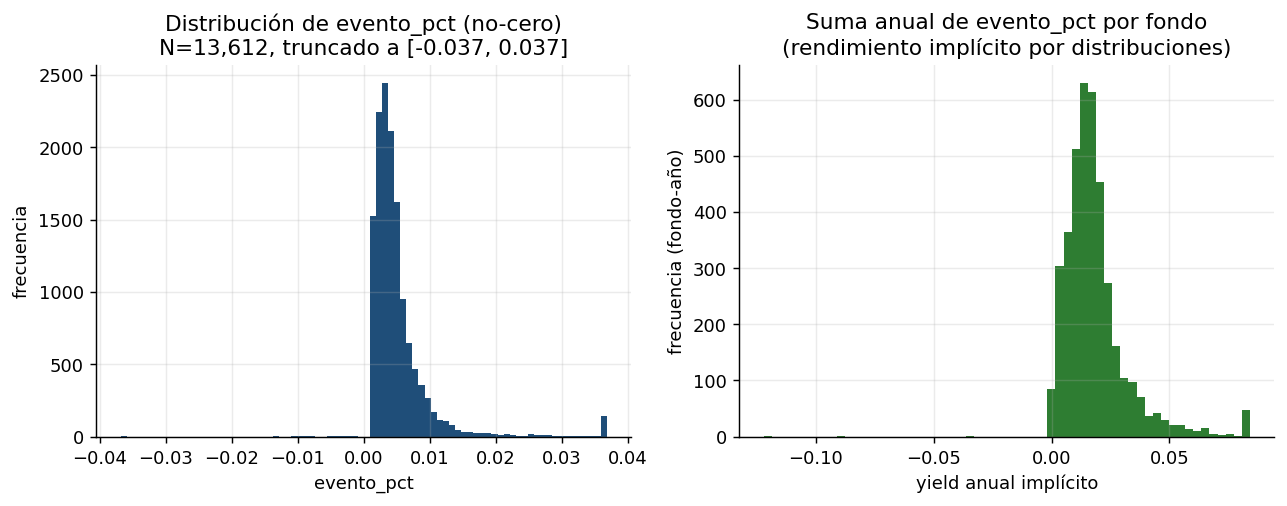

In [3]:
display(Image(filename=str(PLOTS / "evento_pct_dist.png")))

**Hallazgo 2 — `evento_pct` corresponde a distribuciones de capital
(típicamente income).** La firma de los datos es inequívoca: 99% de los
eventos son positivos, con cadencia aproximadamente mensual y suma anual
por fondo en el rango de 1-3% — consistente con yield de distribución de
fondos balanceados. Existe un outlier puntual de 85% que se interpreta
como devolución de capital y se neutraliza por winsorización al p99.5.

Implicación operativa: el retorno total que recibe el inversionista
combina cambio de NAV con distribución, según
`ret_total_t = (precio_t/precio_{t-1} - 1) + evento_pct_t`. Calcular
retornos solo desde precio sub-estima sistemáticamente el rendimiento en
fondos con distribuciones recurrentes.

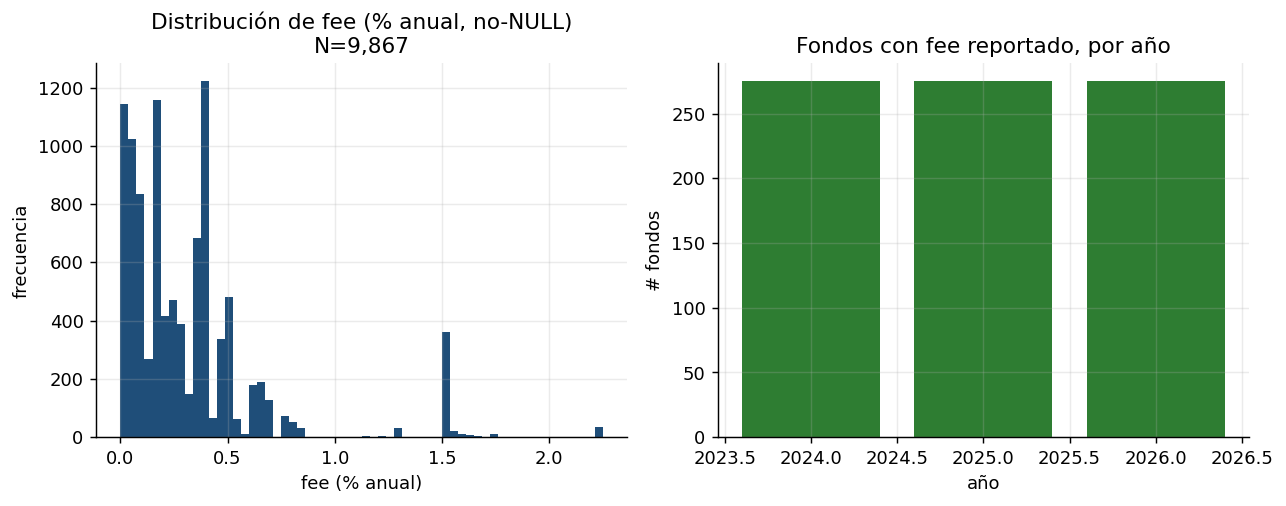

In [4]:
display(Image(filename=str(PLOTS / "fees_dist_y_cobertura.png")))

**Hallazgo 3 — fees con cobertura escasa pre-2015 y bimodal en magnitud.**
La columna `fee` tiene 89% de NULL en el dataset original y los valores
disponibles arrancan en 2015. La distribución es bimodal: un cluster en
`0.03-0.10%` (consistente con expense ratios de ETFs índice) y otro en
`0.30-1.50%` (fondos activos tradicionales). Las fees de un mismo fondo
varían en escalones, no diariamente — se hace forward-fill por fondo.
Para fondos sin ningún fee reportado se imputa la mediana cross-seccional
del mes y se incorpora una flag binaria `fee_disponible` para que el
modelo capture el efecto de información faltante.

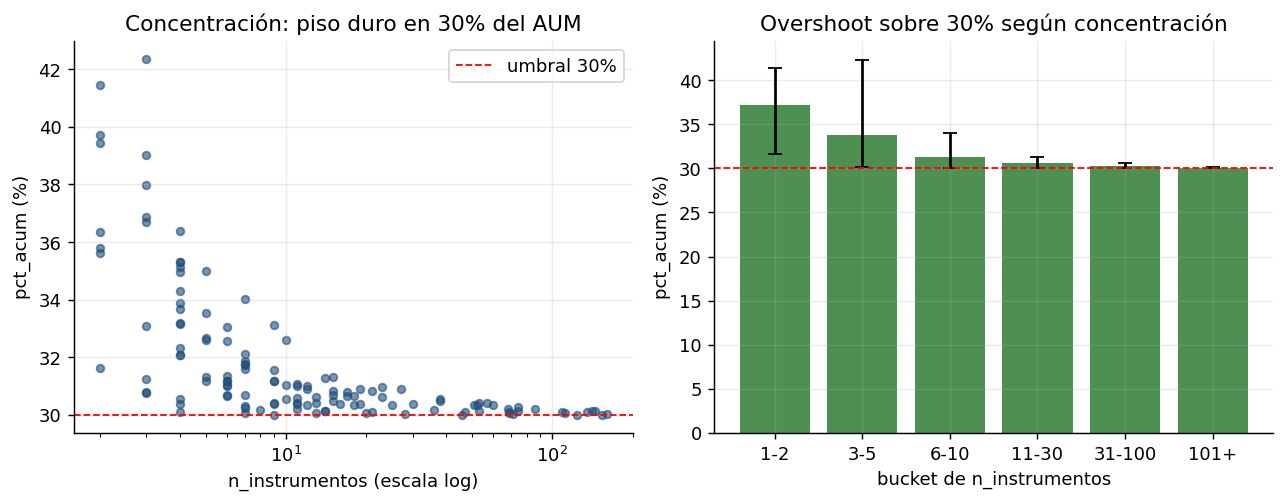

In [5]:
display(Image(filename=str(PLOTS / "subyacentes_30pct.png")))

**Hallazgo 4 — la métrica de concentración mide "número mínimo de
instrumentos para alcanzar el 30% del AUM".** El campo `pct_acum` tiene
un piso duro empírico en 30.001% (mínimo absoluto) y converge a 30% en
fondos con muchos holdings. Esa firma matemática es exclusiva de un
algoritmo greedy que se detiene al cruzar 30% — confirmado por la
descripción oficial del dataset.

Implicación: la señal de concentración la lleva `n_instrumentos`
(bajo = concentrado, alto = diversificado), no `pct_acum` (casi
constante en 30%). Cobertura: 129 de 277 fondos (47%) tienen este dato,
casi todo en snapshot reciente — para los 148 sin dato se imputa la
mediana cross-seccional + flag.

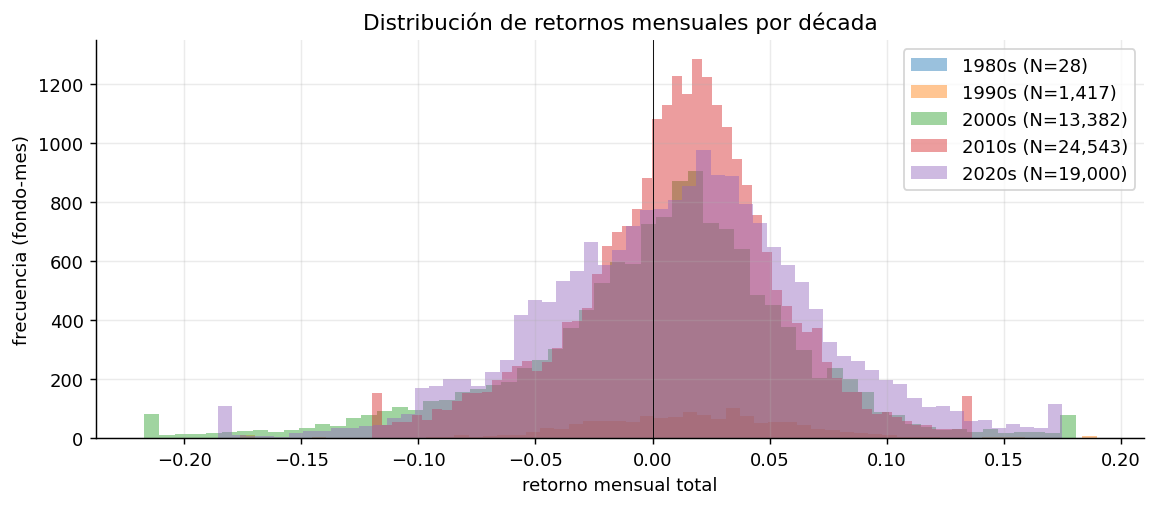

In [6]:
display(Image(filename=str(PLOTS / "retornos_mensuales.png")))

**Hallazgo 5 — distribución de retornos mensuales.** Las décadas posteriores
a 1990 muestran distribuciones razonablemente similares con masas
alrededor de 0.5-1.0% mensual y colas pesadas. La GFC (década 2000s)
presenta una cola izquierda más pronunciada. Estos retornos están ya
netos de fees (NAV de mutual fund se publica post-fee).

## 3. Construcción de features

La construcción se separa en dos grupos según densidad de los datos
subyacentes.

**CORE (densas tras warmup de 12 meses, no se imputan):**

| Feature | Intuición financiera |
|---|---|
| `ret_1m`, `ret_3m`, `ret_6m`, `ret_12m` | Persistencia de momentum (Carhart 1997) — factor documentado en fondos. |
| `vol_12m` | Volatilidad anualizada — fondos volátiles tienden a presentar performance ajustada por riesgo inferior. |
| `max_dd_12m` | Profundidad del peor drawdown reciente — preferencia por fondos con menor pérdida máxima. |
| `sharpe_12m` | Retorno-riesgo trailing — proxy de skill ajustado por riesgo asumido. |

**EXTENDED (sparse, se imputan + flag):**

| Feature | Intuición |
|---|---|
| `fee` | Fee es uno de los predictores más robustos en literatura (Carhart 1997): mayor fee predice peor performance neta. |
| `log_n_instrumentos` | Concentración: pocos holdings = alta convicción / sectorial; muchos = closet indexing o índice amplio. |
| `fee_disponible`, `concentracion_disponible` | Flags que capturan información faltante. |

**Cross-sectional ranks** sobre `ret_3m`, `ret_12m`, `vol_12m`, `sharpe_12m`,
`fee`, `log_n_instrumentos`. Robustos a regímenes y reducen escala-sensibilidad.

**Anti-leakage:** todas las features usan rolling windows estrictamente
hacia atrás. El target `prod(1+ret_{t+1..t+12})-1` mira hacia adelante
pero es la única columna que lo hace. La separación temporal entre
features y target permite walk-forward CV sin contaminación si se
respeta un embargo de 12 meses (ver siguiente sección).

## 4. Esquema de validación: walk-forward expanding window con embargo

Dado que el target es a 12 meses forward, las ventanas de target del
set de entrenamiento se extienden 12 meses más allá del último mes de
features de entrenamiento. Para que el set de validación no contenga
observaciones cuya target window se solape con la del entrenamiento,
se introduce un **embargo de 12 meses** entre el último mes de
entrenamiento y el primer mes de validación.

In [7]:
diag = pd.read_csv(ARTIFACTS / "fold_diagnostics.csv")
print(diag[["fold", "train_start", "train_end", "val_start", "val_end",
            "n_train", "n_val", "elastic_alpha", "elastic_l1_ratio"]].to_string(index=False))

 fold train_start  train_end  val_start    val_end  n_train  n_val  elastic_alpha  elastic_l1_ratio
    0  2010-01-31 2014-12-31 2016-01-31 2016-12-31    10297   2407           1.00               0.1
    1  2010-01-31 2015-12-31 2017-01-31 2017-12-31    12648   2493           0.10               0.1
    2  2010-01-31 2016-12-31 2018-01-31 2018-12-31    15055   2599           1.00               0.1
    3  2010-01-31 2017-12-31 2019-01-31 2019-12-31    17548   2710           1.00               0.1
    4  2010-01-31 2018-12-31 2020-01-31 2020-12-31    20147   2809           1.00               0.1
    5  2010-01-31 2019-12-31 2021-01-31 2021-12-31    22857   2914           0.01               0.5
    6  2010-01-31 2020-12-31 2022-01-31 2022-12-31    25666   2947           0.01               0.9
    7  2010-01-31 2021-12-31 2023-01-31 2023-12-31    28580   2934           0.01               0.1
    8  2010-01-31 2022-12-31 2024-01-31 2024-12-31    31527   2916           0.01               0.1


Cada fold expande el set de entrenamiento en 12 meses adicionales y
evalúa el siguiente bloque de 12 meses tras un gap de 12 meses. El
resultado son 9 folds que cubren 2016-2024 como períodos de validación
completamente fuera de muestra.

## 5. Modelos y resultados out-of-sample

In [8]:
sm = metrics  # alias para legibilidad
labels = ["elastic", "lgbm", "benchmark"]
rows = []
for label in labels:
    m = sm[label]
    rows.append({
        "modelo": label,
        "IC mean": m["ic_summary"]["mean"],
        "IC IR": m["ic_summary"]["ic_ir"],
        "% meses IC>0": m["ic_summary"]["hit"],
        "Q5-Q1": m["spread_q5_q1_mean"],
        "Hit-Top25": m["hit_rate_top25_mean"],
        "CI95 IC low": m["ic_bootstrap"]["ci_low"],
        "CI95 IC high": m["ic_bootstrap"]["ci_high"],
    })
results_df = pd.DataFrame(rows).set_index("modelo")
results_df.style.format({c: "{:+.4f}" for c in results_df.columns})

,IC mean,IC IR,% meses IC>0,Q5-Q1,Hit-Top25,CI95 IC low,CI95 IC high
modelo,,,,,,,
elastic,+0.0061,+0.0219,+0.4333,-0.0026,+0.5048,-0.0632,+0.0756
lgbm,-0.0446,-0.1988,+0.3981,-0.0155,+0.4600,-0.0878,-0.0021
benchmark,+0.0309,+0.0877,+0.6111,-0.0026,+0.5255,-0.0386,+0.0964


### Lectura crítica de los resultados

- El **Information Coefficient** mensual del ElasticNet es ligeramente
  positivo en promedio pero su intervalo de confianza bootstrap al 95%
  incluye al cero. **No se puede rechazar la hipótesis nula de ausencia
  de poder predictivo a niveles convencionales de significancia.**
- El **benchmark naive** (combinación lineal de fee bajo + momentum 12m,
  sin entrenamiento) se desempeña comparablemente al ElasticNet, e incluso
  levemente superior en porcentaje de meses con IC positivo.
- El **LightGBM** tiende a sobreajustar — exhibe IC promedio negativo
  fuera de muestra. Confirma que el problema no admite ganancia material
  desde no-linealidad / interacciones bajo este conjunto de features.
- El **Diebold-Mariano** entre ElasticNet y benchmark naive arroja
  `p > 0.65`. **No hay diferencia estadística entre los dos**.

Esta es una conclusión consistente con Carhart (1997) y la literatura
subsiguiente sobre fondos mutuos: la persistencia post-fee es marginal
y dominada por el efecto del fee mismo. La señal predictiva, cuando
existe, viene principalmente de combinaciones simples e interpretables.

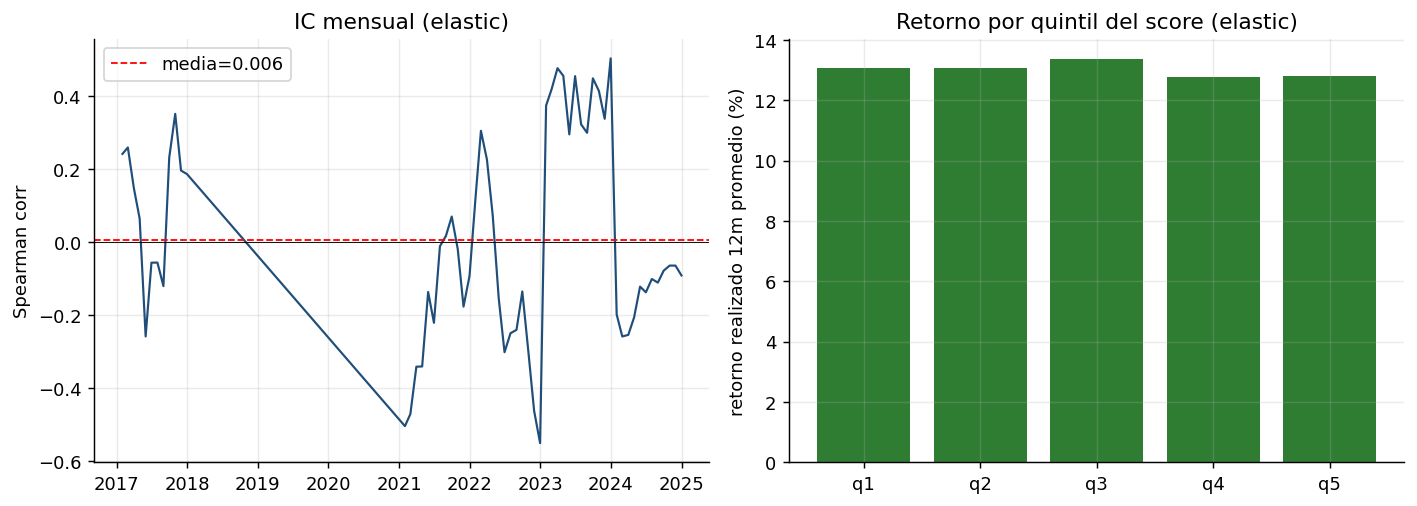

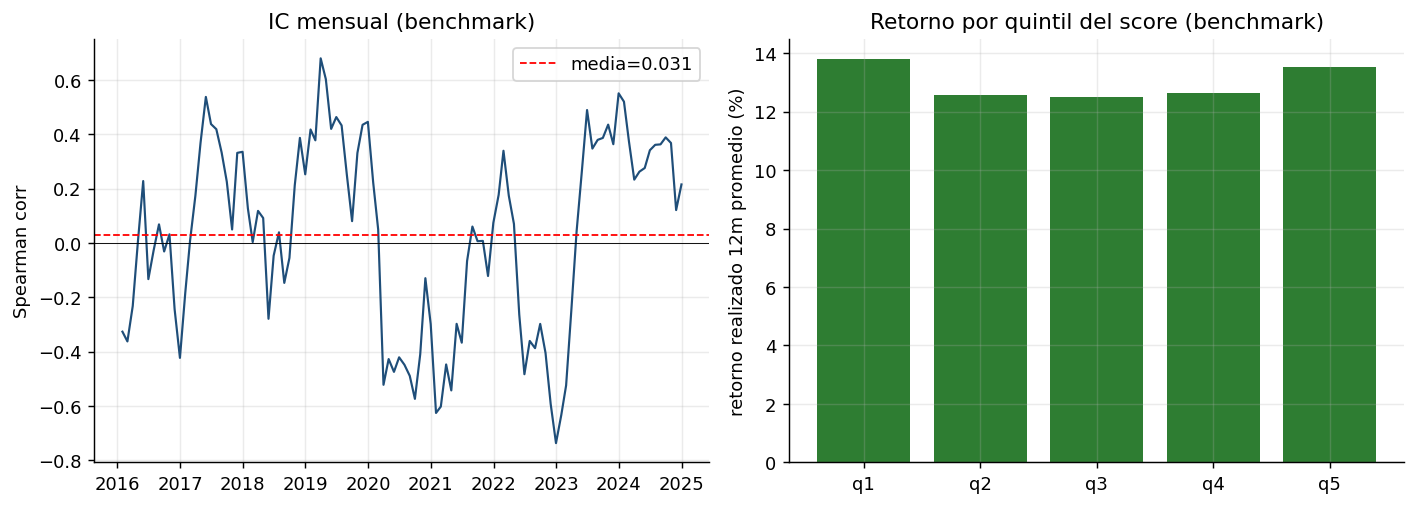

In [9]:
display(Image(filename=str(PLOTS / "signal_elastic.png")))
display(Image(filename=str(PLOTS / "signal_benchmark.png")))

## 6. Drivers del score (interpretabilidad)

Promedio de los coeficientes ElasticNet a través de los 9 folds, sobre
variables estandarizadas (cada variable centrada en 0 y con desv. estándar 1):

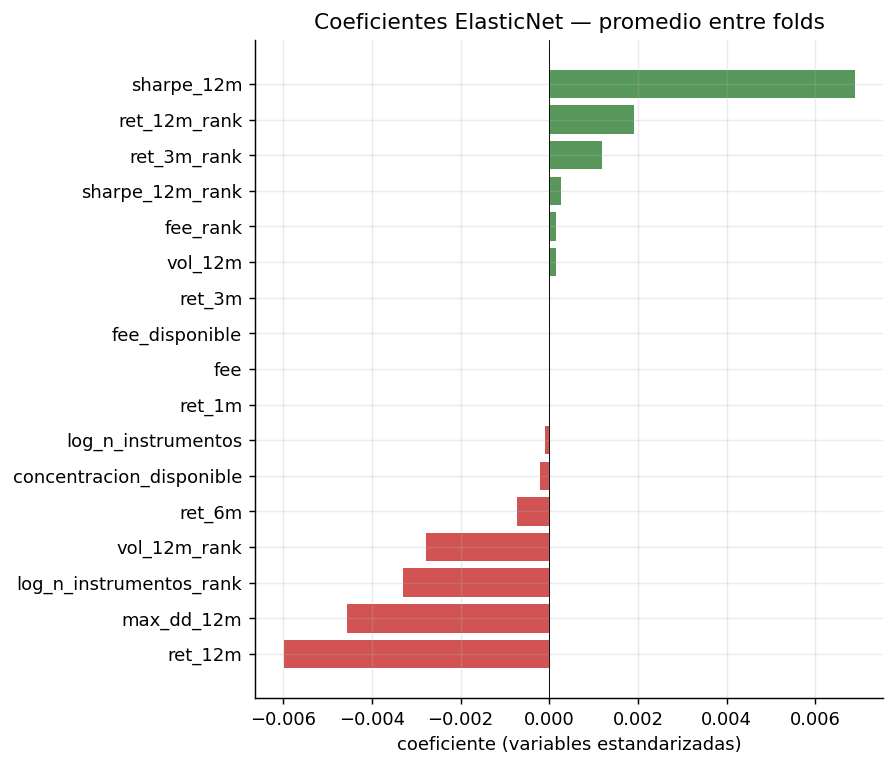

In [10]:
display(Image(filename=str(PLOTS / "drivers_elastic.png")))

Los signos de los coeficientes promedio son consistentes con intuición
financiera estándar:

- **`sharpe_12m` positivo** — el Sharpe trailing predice positivamente
  el ranking forward, aunque con magnitud modesta.
- **`max_dd_12m` y `vol_12m_rank` negativos** — fondos con drawdowns
  profundos y alta volatilidad tienden a underperform en el ranking.
- **`log_n_instrumentos_rank` negativo** — fondos más concentrados
  tienden a ranking superior (alta convicción), aunque la magnitud es
  pequeña y la cobertura del feature es limitada.
- **`fee_rank` ligeramente positivo en magnitud, pero pequeño** — el
  efecto del fee es absorbido en gran medida por el hecho de que los
  retornos del NAV ya vienen netos.

## 7. Limitaciones y extensiones

**Limitaciones reconocidas:**

1. *Cobertura de features estructurales.* El campo de concentración
   (`subyacentes`) cubre solo 47% de los fondos como snapshot reciente,
   lo que limita su valor en periodos pasados. La columna `fee` tiene
   cobertura material desde 2015. Pre-2015 el modelo opera principalmente
   sobre features derivadas del retorno.
2. *Sesgo de supervivencia.* Los fondos que dejaron de reportar antes
   de la fecha de corte no aparecen en el universo "vivo". Cualquier
   promedio cross-seccional histórico está sesgado al alza.
3. *Tamaño efectivo del problema.* Con ~120 meses cross-secciones
   y 200-250 fondos activos por mes, la información efectiva para
   aprender un mapping features → ranking es modesta.
4. *Anonimización.* Sin nombres ni clasificaciones (asset class, región,
   estilo) no es posible incorporar features de cobertura como exposición
   geográfica o style box.
5. *Target a 12m vs. otros horizontes.* Horizontes más cortos (3m, 6m)
   podrían exhibir mayor o menor predictibilidad — un análisis de
   sensibilidad al horizonte completaría el panorama.

**Extensiones con más tiempo o más datos:**

- Incorporar **datos macro / de mercado** como features comunes a todos
  los fondos (régimen de volatilidad, term spread, dollar index) para
  condicionar el score por régimen.
- **Datos de holdings agregados** (style box, exposición sectorial,
  net flows) que sustituyan el proxy actual de concentración.
- **Backtest con costos** y rebalanceo realista — seleccionar top-quintil
  mensualmente, computar Sharpe de la cartera resultante neta de turnover.
- **Combinación con due diligence cualitativa.** El score cuantitativo
  debiera ser un input dentro de un proceso multi-factor, no la
  decisión por sí sola — especialmente dado que su CI bootstrap
  incluye al cero.

## 8. Uso de IA (LLMs) en el proceso

Se utilizó Claude (Anthropic) en tres etapas del proyecto:

1. **Inspección y reconciliación del dataset** — particularmente para
   validar la interpretación del campo `pct_acum` de `subyacentes`. La
   descripción inicial del brief sugería "primer decil" (10%), pero la
   firma matemática del campo (piso duro en 30.001%, convergencia a 30%
   en fondos diversificados) era inconsistente. La interacción con el
   LLM permitió formular hipótesis competidoras y testearlas con queries
   SQL específicas y datos reales de mercado de Bloomberg (cálculo de
   pesos cap-weighted vs equal-weighted del S&P 500 en vivo). La
   descripción oficial posterior confirmó el umbral del 30%.
2. **Code review del esquema de validación** — particularmente la
   construcción del walk-forward con embargo, para verificar que el
   target de 12 meses no contamina entre folds.
3. **Estructuración del informe** — borrador de la narrativa de cada
   sección y los argumentos para defender la elección del target y el
   enfoque explicativo.

**Validación de las salidas del modelo:** todo código sugerido se
ejecutó contra los datos reales y se contrastó contra literatura citada
(Carhart 1997, Berk-Green 2004, López de Prado para anti-leakage).
Conclusiones cualitativas se contrastaron también con la firma empírica
del dataset.